In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1. Chargement des données
df_histo = pd.read_csv("historique_frais.csv", sep=";", encoding="utf-8")
df_budget = pd.read_csv("budget_alloue.csv", sep=";", encoding="utf-8")

In [3]:
# 2. Nettoyage et préparation
df_histo.columns = df_histo.columns.str.strip()
df_histo["Montant"] = pd.to_numeric(df_histo["Montant"], errors="coerce").fillna(0)

In [4]:
# 3. Paramètres de l'année cible
annee_cible = 2025
annees_historiques = [annee_cible - 3, annee_cible - 2, annee_cible - 1]

mois_order = ["janv", "fev", "mar", "avr", "mai", "juin", 
              "juill", "aout", "sep", "oct", "nov", "dec"]
df_histo = df_histo[df_histo["Mois"].isin(mois_order)]
df_histo["Mois"] = pd.Categorical(df_histo["Mois"], categories=mois_order, ordered=True)

In [5]:
# 4. Filtrage historique
histo_filtre = df_histo[df_histo["Annee"].isin(annees_historiques)]

In [6]:
# 5. Calcul des moyennes mensuelles par catégorie
pivot = histo_filtre.pivot_table(
    index=["Mois"],
    columns="Categorie",
    values="Montant",
    aggfunc="mean",
    fill_value=0,
    observed=False
)

In [7]:
# 6. Calcul des ratios mensuels par catégorie
total_annuel = pivot.sum(axis=0)
df_ratios = pivot.divide(total_annuel, axis=1).fillna(0)

In [8]:
# 7. Application des budgets alloués
repartition = pd.DataFrame(index=mois_order)
for _, row in df_budget.iterrows():
    cat = row["Categorie"]
    budget = row["Budget_Alloue"]
    if cat in df_ratios.columns:
        repartition[cat] = df_ratios[cat] * budget
    else:
        repartition[cat] = 0
repartition.index.name = "Mois"
repartition = repartition.reset_index()

In [9]:
# 8. Transformation en format long pour visualisation
df_resultat = pd.melt(
    repartition,
    id_vars=["Mois"],
    var_name="Categorie",
    value_name=f"Montant_{annee_cible}"
)

In [10]:
# 9. Calculs additionnels pour reporting
repartition["Total_Mensuel"] = repartition.drop(columns=["Mois"]).sum(axis=1)
total_par_categorie = repartition.drop(columns=["Mois", "Total_Mensuel"]).sum()
total_general_annuel = total_par_categorie.sum()

print("Total par catégorie (annuel):")
print(total_par_categorie)
print("\nTotal général annuel:", total_general_annuel)

Total par catégorie (annuel):
Dotations aux Amrt & Prov                      120000000.0
Frais de personnel                             738431082.0
Frais divers de gestion                        475766000.0
Impôts et taxes                                194260066.0
Transports et déplacements                      27000000.0
Travaux, fournitures et services extérieurs    622592600.0
dtype: float64

Total général annuel: 2178049748.0


In [11]:
# 10. Graphiques
sns.set(style="whitegrid")

C:\Users\theAr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\theAr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


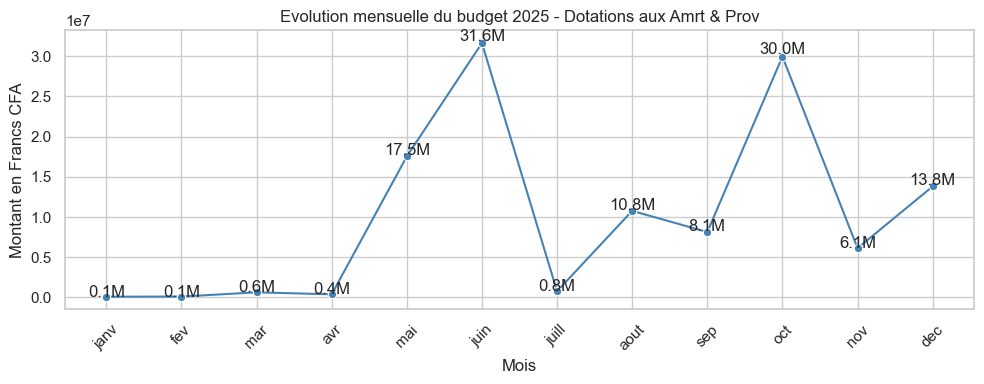

C:\Users\theAr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\theAr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


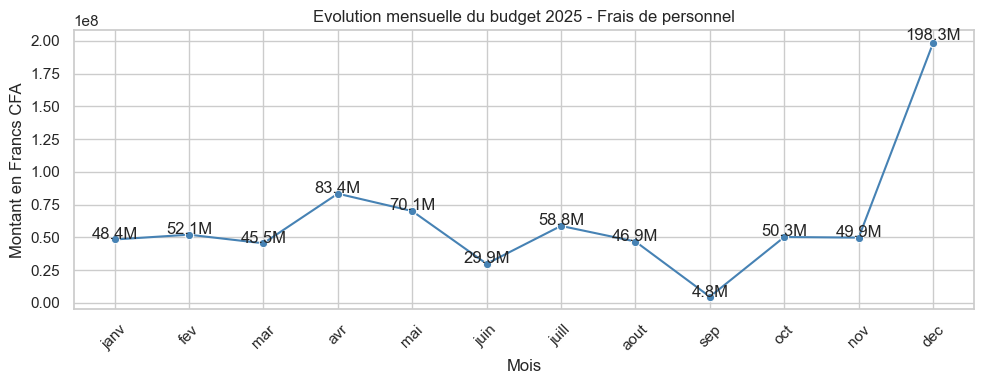

C:\Users\theAr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\theAr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


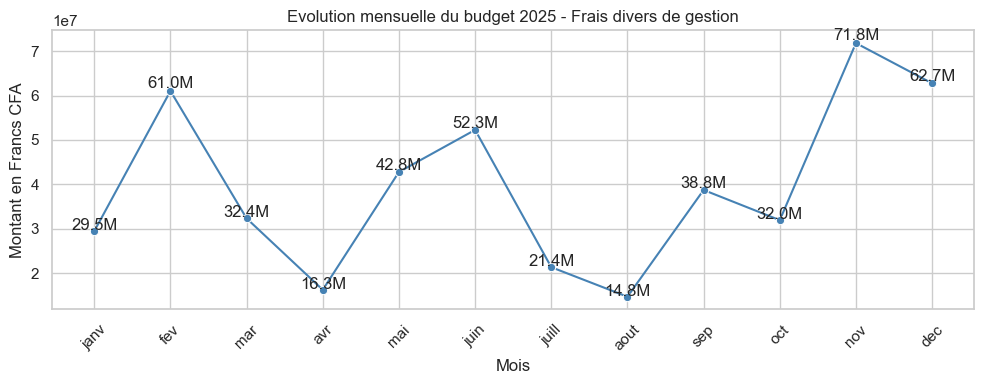

C:\Users\theAr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\theAr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


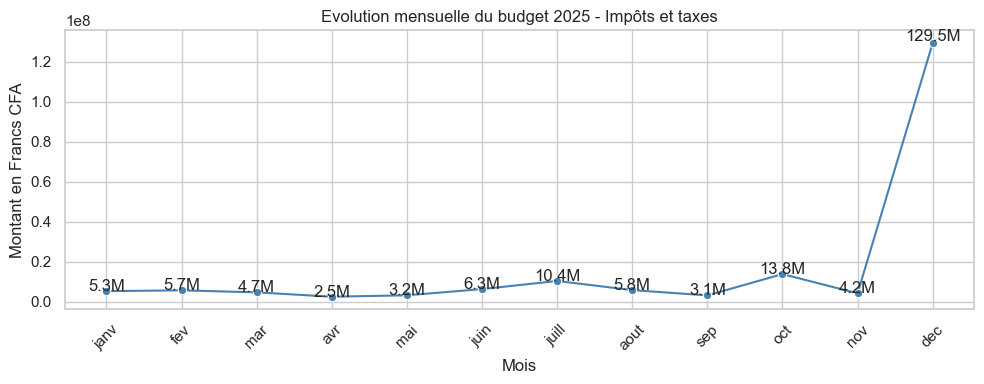

C:\Users\theAr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\theAr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


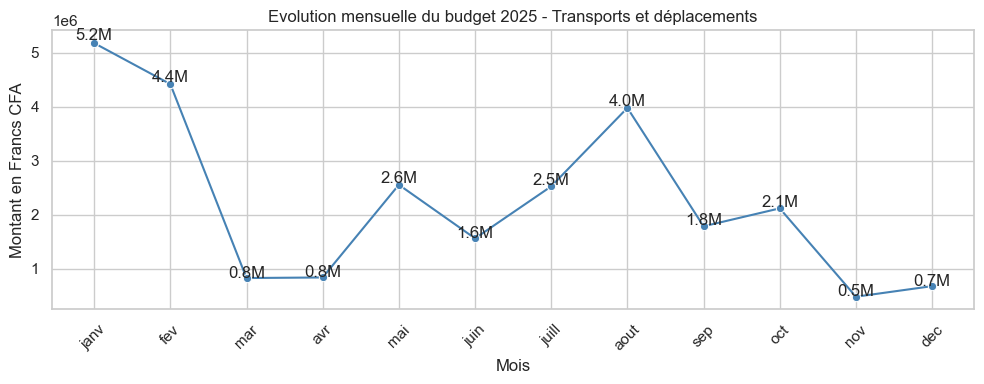

C:\Users\theAr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\theAr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


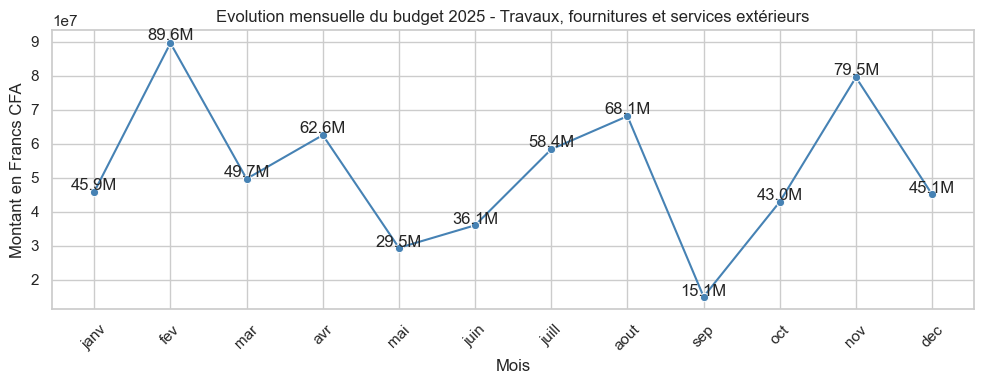

In [12]:
# a. Graphiques d'évolution individuelle par catégorie
for categorie in df_resultat["Categorie"].unique():
    df_cat = df_resultat[df_resultat["Categorie"] == categorie]
    plt.figure(figsize=(10, 4))
    ax = sns.lineplot(data=df_cat, x="Mois", y=f"Montant_{annee_cible}", marker="o", color="steelblue")
    for i, row in df_cat.iterrows():
        ax.text(row["Mois"], row[f"Montant_{annee_cible}"] * 1.01, f"{row[f'Montant_{annee_cible}']/1e6:.1f}M", ha='center')
    plt.title(f"Evolution mensuelle du budget {annee_cible} - {categorie}")
    plt.ylabel("Montant en Francs CFA")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

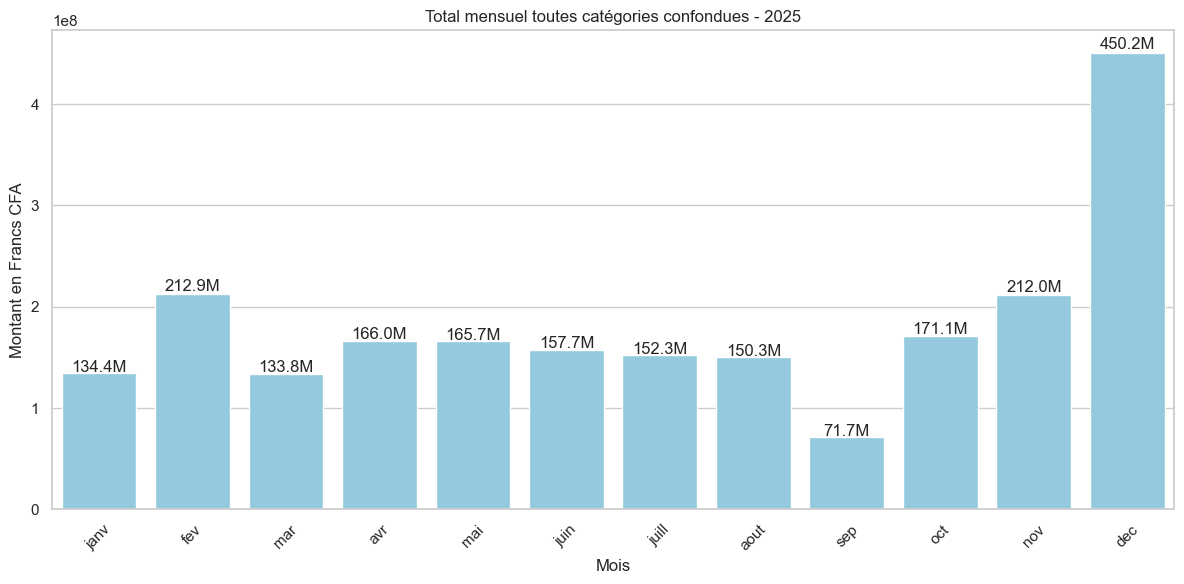

In [13]:
# b. Barplot des totaux mensuels toutes catégories
plt.figure(figsize=(12, 6))
ax = sns.barplot(x="Mois", y="Total_Mensuel", data=repartition, color="skyblue")
for i, val in enumerate(repartition["Total_Mensuel"]):
    ax.text(i, val * 1.01, f"{val/1e6:.1f}M", ha='center')
plt.title(f"Total mensuel toutes catégories confondues - {annee_cible}")
plt.ylabel("Montant en Francs CFA")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

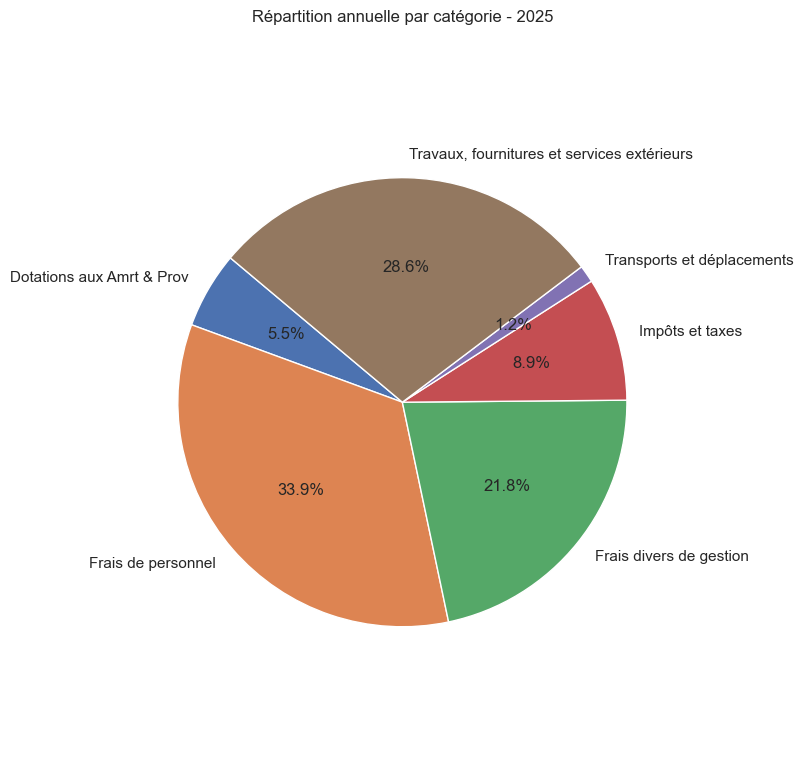

In [14]:
# c. Pie chart des totaux annuels par catégorie
plt.figure(figsize=(8, 8))
plt.pie(total_par_categorie, labels=total_par_categorie.index, autopct="%1.1f%%", startangle=140)
plt.title(f"Répartition annuelle par catégorie - {annee_cible}")
plt.axis("equal")
plt.tight_layout()
plt.show()

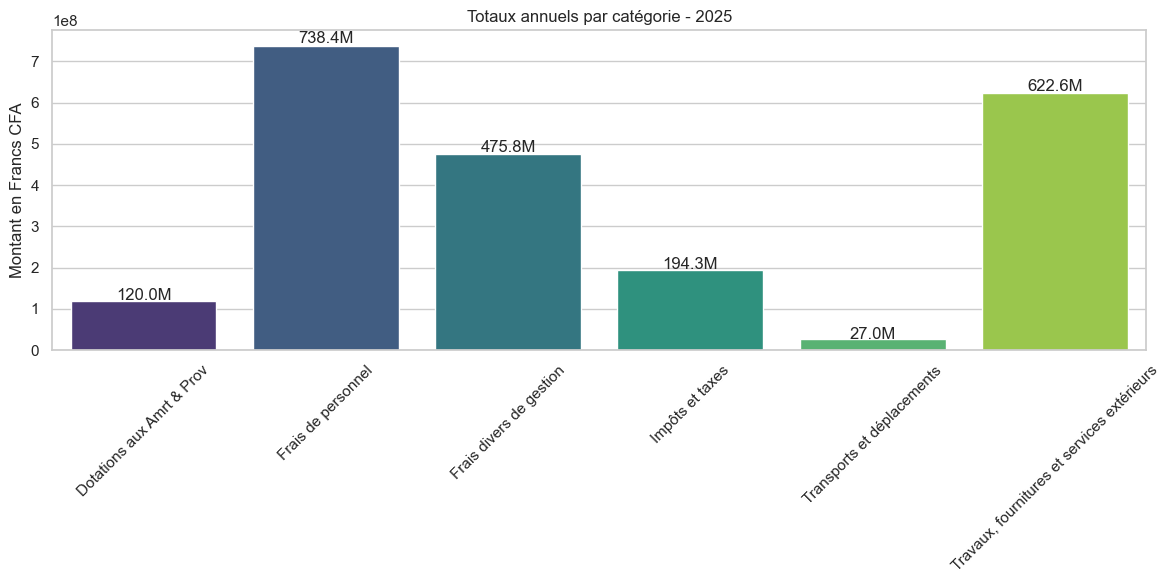

In [15]:
# d. Barplot des totaux annuels par catégorie
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=total_par_categorie.index, y=total_par_categorie.values, palette="viridis")
for i, val in enumerate(total_par_categorie):
    ax.text(i, val * 1.01, f"{val/1e6:.1f}M", ha='center')
plt.title(f"Totaux annuels par catégorie - {annee_cible}")
plt.ylabel("Montant en Francs CFA")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
# 11. Export (optionnel)
df_resultat.to_csv(f"budget_{annee_cible}_reparti.csv", sep=";", index=False)

In [19]:
# 12. Préparation des données 2025 à ajouter dans le format historique
df_resultat["Annee"] = annee_cible
df_resultat = df_resultat.rename(columns={f"Montant_{annee_cible}": "Montant"})
df_resultat = df_resultat[["Annee", "Mois", "Categorie", "Montant"]]

# 13. Ajout dans l'historique proprement
df_histo = pd.concat([df_histo, df_resultat], ignore_index=True)

# 14. Sauvegarde de l'historique mis à jour
df_histo.to_csv("historique_frais.csv", sep=";", index=False, encoding="utf-8")

print(f"✅ Données {annee_cible} intégrées dans l'historique.")

✅ Données 2025 intégrées dans l'historique.
